<a href="https://colab.research.google.com/github/100522371/P1_AA_Grupo17/blob/main/p1_aa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Exploratory Data Analysis

Primero, importamos los datos disponibles al almacenamiento de sesión de Google Collab. Sumamos los últimos dos digitos de nuestras NIAs, 71 + 40 = 111, por lo que utilizaremos bank_11.pkl

In [47]:
try:
    from google.colab import files
    uploaded = files.upload()  # Solo se ejecuta en Colab
except ImportError:
    pass  # Ejecutando en local, el fichero ya debe estar presente

In [48]:
import pandas as pd

df = pd.read_pickle('bank_11.pkl')

# Para comprobar que se ha cargado bien vemos las primeras filas.
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,None,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


## Variables e instancias


In [49]:
# Número de instancias
print(df.shape[0])
# Número de variables
print(df.shape[1])

11000
17


## Data types y valores faltantes

Con el método info() podemos obtener información general como el data type de cada columna y cuantos valores nulos hay.

In [50]:
df.info()

<class 'pandas.DataFrame'>
Index: 11000 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11000 non-null  int64 
 1   job        11000 non-null  object
 2   marital    10634 non-null  object
 3   education  11000 non-null  object
 4   default    11000 non-null  object
 5   balance    11000 non-null  int64 
 6   housing    11000 non-null  object
 7   loan       11000 non-null  object
 8   contact    11000 non-null  object
 9   day        11000 non-null  int64 
 10  month      11000 non-null  object
 11  duration   11000 non-null  int64 
 12  campaign   11000 non-null  int64 
 13  pdays      11000 non-null  int64 
 14  previous   11000 non-null  int64 
 15  poutcome   11000 non-null  object
 16  deposit    11000 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.5+ MB


Podemos ver que la única columna con valores nulos es marital, con 366 valores nulos

## Cardinalidad

In [51]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns
alta_cardinalidad = [col for col in cat_cols if df[col].nunique() > 10]
print("Variables categóricas con más de 10 valores únicos:")
for col in alta_cardinalidad:
    print(f"- {col}: {df[col].nunique()} valores únicos")

Variables categóricas con más de 10 valores únicos:
- job: 12 valores únicos
- month: 12 valores únicos


Tiene sentido que job y month sean variables de alta cardinalidad

## Columnas constantes y de ID

Una columna constante tiene 1 solo valor para todas las filas. Un ID tiene tantos valores únicos como filas tenga el dataset.

In [52]:
# Columnas constantes
constantes = [col for col in df.columns if df[col].nunique() == 1]
print(f"Columnas constantes: {constantes}")

# Columnas tipo ID
ids = [col for col in df.columns if df[col].nunique() == len(df)]
print(f"Columnas que parecen IDs: {ids}")

Columnas constantes: []
Columnas que parecen IDs: []


Es interesante identificar que valores pueden tomar las variables categóricas

In [53]:
for col in cat_cols:
  valores_unicos = df[col].unique()
  cantidad = len(valores_unicos)
  print(f"--- Variable: {col} ---")
  print(f"Cantidad de valores únicos: {cantidad}")
  print(f"Valores: {valores_unicos}")
  print("-" * 50) # Línea separadora para que se lea mejor

--- Variable: job ---
Cantidad de valores únicos: 12
Valores: ['admin.' 'technician' 'services' 'management' 'retired' 'blue-collar'
 'unemployed' 'entrepreneur' 'housemaid' 'unknown' 'self-employed'
 'student']
--------------------------------------------------
--- Variable: marital ---
Cantidad de valores únicos: 4
Valores: ['married' None 'single' 'divorced']
--------------------------------------------------
--- Variable: education ---
Cantidad de valores únicos: 4
Valores: ['secondary' 'tertiary' 'primary' 'unknown']
--------------------------------------------------
--- Variable: default ---
Cantidad de valores únicos: 2
Valores: ['no' 'yes']
--------------------------------------------------
--- Variable: housing ---
Cantidad de valores únicos: 2
Valores: ['yes' 'no']
--------------------------------------------------
--- Variable: loan ---
Cantidad de valores únicos: 2
Valores: ['no' 'yes']
--------------------------------------------------
--- Variable: contact ---
Cantidad de

Podemos ver que algunas variables no tienen instancias None pero si unknown, ¿sería adecuado considerar unknown equivalente a None?

Investigando por internet hemos llegado a la conclusión que el hecho de que un dato sea desconocido tiene valor predictivo por sí mismo. Por ejemplo, si el banco no conoce el historial crediticio (default) de un cliente, eso en sí mismo ya es un indicador de riesgo.

En nuestro caso, default no tiene valores desconocidos. Los que si tienen unknown son: job, education, contact y poutcome. De estas variables, creo que todas tienen cierto valor predictivo.

## Tipo de problema

Como la variable objetivo es deposit, cuyos valores son categóricos, estamos ante un problema de clasificación. Para ver si está desbalanceado:

In [54]:
# Frecuencia absoluta
print("Recuento de clases en 'deposit':\n", df['deposit'].value_counts())

# Frecuencia relativa (porcentaje)
print("\nPorcentaje de clases en 'deposit':\n", df['deposit'].value_counts(normalize=True) * 100)

Recuento de clases en 'deposit':
 deposit
no     5780
yes    5220
Name: count, dtype: int64

Porcentaje de clases en 'deposit':
 deposit
no     52.545455
yes    47.454545
Name: proportion, dtype: float64


Tras analizar la variable objetivo deposit, comprobamos que nos enfrentamos a un problema de clasificación balanceado. Las clases están distribuidas de forma muy equitativa (52.5% frente a 47.5%), por lo que no será necesario aplicar técnicas de corrección de desbalanceo en el diseño de nuestras pipelines.

## pdays

Se pide que analizemos particularmente la variable pdays, y describir como se va a realizar el preproceso de esta variable (y llevar a cabo el preproceso ya en esta sección, si eso se considera correcto).

In [55]:
print("Distribución de la variable 'pdays':")
print(df['pdays'].value_counts().head(10)) # Vemos los valores más comunes, seguramente -1 sea el mayoritario

# Comprobar cuántos son -1 exactamente
sin_contacto = (df['pdays'] == -1).sum()
porcentaje = (sin_contacto / len(df)) * 100
print(f"\nHay {sin_contacto} instancias con valor -1 ({porcentaje:.2f}% del total).")

Distribución de la variable 'pdays':
pdays
-1      8203
 92      105
 182      88
 91       82
 181      79
 183      73
 184      51
 94       42
 93       40
 95       37
Name: count, dtype: int64

Hay 8203 instancias con valor -1 (74.57% del total).


El análisis de pdays revela que el 74.57% de las instancias tienen el valor -1, lo que indica que la inmensa mayoría de los clientes no fueron contactados en la campaña anterior (o se desconoce). Dado que -1 representa una ausencia de contacto y no un valor numérico real de días, dejarlo tal cual afectaría negativamente a modelos basados en distancias (como KNN). Por tanto, en la fase de preprocesado vamos a convertirlo a categórica, donde -1 -> "Sin contacto". Las otras categorías serán: "contacto reciente", "contacto medio" y "contacto antiguo". Ahora debemos decidir cuales serán los umbrales.


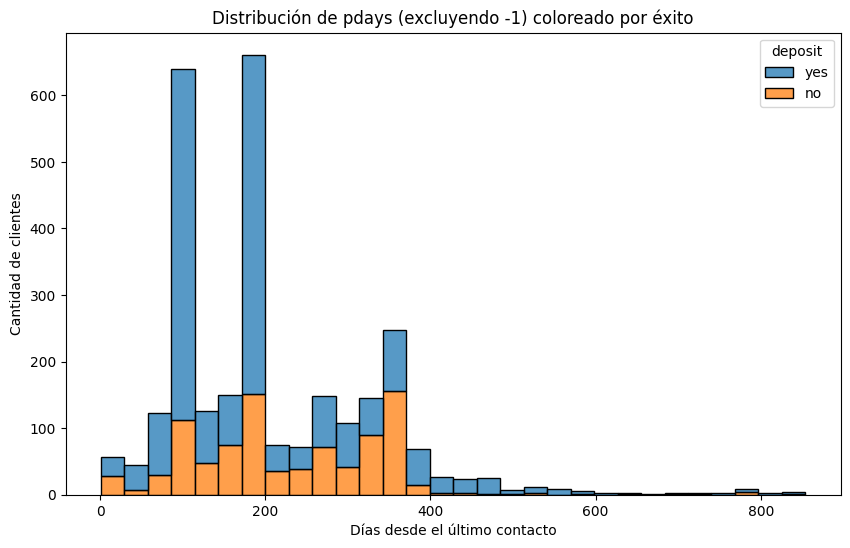

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

# Creamos un dataframe solo con los contactados
df_contactados = df[df['pdays'] != -1].copy()

# Hacemos un histograma coloreado por si suscribieron o no el depósito
plt.figure(figsize=(10, 6))
sns.histplot(data=df_contactados, x='pdays', hue='deposit', multiple="stack", bins=30)
plt.title("Distribución de pdays (excluyendo -1) coloreado por éxito")
plt.xlabel("Días desde el último contacto")
plt.ylabel("Cantidad de clientes")
plt.show()

Los contactos antes de los 200 días presentan una alta proporción de respuestas positivas. A partir de los 200 días la proporción se iguala un poco, y al superar el año (>400 días) las respuestas en general decrecen enormemente. Por ello, se categorizará la variable usando estos umbrales críticos detectados visualmente. 0-200 = "contacto reciente", 201-400 = "contacto medio" y >401 = "contacto antiguo".

In [57]:
import pandas as pd
import numpy as np

# 1. Definimos los cortes (bins)
cortes = [-np.inf, -1, 200, 400, np.inf]

# 2. Definimos las etiquetas
etiquetas = [
    'no_contact',
    'recent',
    'intermediate',
    'old'
]

# 3. Sobrescribimos la columna original directamente
df['pdays'] = pd.cut(df['pdays'], bins=cortes, labels=etiquetas, right=True)

# Comprobamos el resultado
print(df['pdays'].value_counts())

pdays
no_contact      8203
recent          1799
intermediate     865
old              133
Name: count, dtype: int64


In [58]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,no_contact,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,no_contact,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,no_contact,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,no_contact,0,unknown,yes
4,54,admin.,None,tertiary,no,184,no,no,unknown,5,may,673,2,no_contact,0,unknown,yes



## EVALUACIÓN

## Decidir cómo se va a realizar la evaluación

### Métrica elegida: ROC-AUC

La métrica elegida para este problema es **ROC-AUC** (Area Under the Receiver Operating Characteristic Curve).

Esta métrica mide la capacidad del modelo para distinguir entre clases positivas (`yes`) 
y negativas (`no`) a lo largo de todos los umbrales de decisión posibles. Un valor de 1.0 
indica un modelo perfecto, mientras que 0.5 equivale a predicción aleatoria.

Se ha elegido ROC-AUC por las siguientes razones:
- Es **independiente del umbral**: el banco puede decidir más adelante cuántos clientes 
  contactar según su presupuesto, sin que eso afecte a la evaluación del modelo.
- Es más **informativa que la accuracy**, ya que mide la calidad del ranking de predicciones 
  y no solo si la clase predicha es correcta.
- Es compatible con todos los modelos que producen probabilidades o puntuaciones 
  (KNN, árboles, regresión logística, SVM).
- Aunque el dataset está relativamente balanceado (52% / 48%), ROC-AUC sigue siendo 
  la elección más robusta y profesional.


In [59]:
from sklearn.model_selection import train_test_split, StratifiedKFold

SEED = 100477240  # NIA utilizado como semilla para reproducibilidad

# Separamos las variables predictoras (X) de la variable objetivo (y)
X = df.drop(columns=['deposit'])
y = df['deposit']


### Evaluación externa (outer): Holdout

La estimación del rendimiento futuro del modelo se realizará mediante **Holdout**:
- **Train (2/3)**: usado para entrenar modelos, optimizar hiperparámetros y comparar alternativas.
- **Test (1/3)**: reservado exclusivamente para la evaluación final del modelo elegido.

In [60]:
# División Holdout estratificada: 2/3 train, 1/3 test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=1/3,
    random_state=SEED,
    stratify=y        # mantiene la proporción de clases en ambos conjuntos
)

print(f"Tamaño del conjunto de entrenamiento: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Tamaño del conjunto de test:          {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")
print(f"\nDistribución de clases en train:\n{y_train.value_counts(normalize=True)*100}")
print(f"\nDistribución de clases en test:\n{y_test.value_counts(normalize=True)*100}")


Tamaño del conjunto de entrenamiento: 7333 (66.7%)
Tamaño del conjunto de test:          3667 (33.3%)

Distribución de clases en train:
deposit
no     52.543297
yes    47.456703
Name: proportion, dtype: float64

Distribución de clases en test:
deposit
no     52.549768
yes    47.450232
Name: proportion, dtype: float64


### Evaluación interna (inner): Validación cruzada estratificada

Para la comparación de modelos y la optimización de hiperparámetros (HPO) se utilizará 
**StratifiedKFold con 5 particiones**.

- Divide el conjunto de train en 5 partes iguales (folds).
- En cada iteración, entrena con 4 folds y evalúa con el restante.
- Repite esto 5 veces, usando cada fold como test exactamente una vez.
- El resultado final es la media de las 5 puntuaciones → estimación estable del rendimiento.

Se usa la versión **estratificada** para garantizar que cada fold mantenga 
la misma proporción de clases (~52% no / 48% yes), evitando folds con distribuciones 
desiguales que darían estimaciones poco fiables.

Esta evaluación interna se usará en la mayor parte de la práctica. Solo al final, 
una vez elegido el mejor modelo, se usará el conjunto de test (evaluación outer).


In [61]:
# Validación cruzada interna: StratifiedKFold con 5 particiones
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Métrica utilizada en toda la práctica
METRIC = "roc_auc"

print("Configuración de evaluación:")
print(f"  - Evaluación outer: Holdout (2/3 train / 1/3 test), estratificado")
print(f"  - Evaluación inner: StratifiedKFold (k=5), estratificado, semilla={SEED}")
print(f"  - Métrica: {METRIC}")


Configuración de evaluación:
  - Evaluación outer: Holdout (2/3 train / 1/3 test), estratificado
  - Evaluación inner: StratifiedKFold (k=5), estratificado, semilla=100477240
  - Métrica: roc_auc
